In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import LSTM

In [9]:
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv('GOOGL.csv')
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,50.050049,52.082081,48.028027,50.220219,50.220219,44659096
1,2004-08-20,50.555557,54.594597,50.300301,54.209209,54.209209,22834343
2,2004-08-23,55.430431,56.796799,54.579578,54.754753,54.754753,18256126
3,2004-08-24,55.675674,55.855858,51.836838,52.487488,52.487488,15247337
4,2004-08-25,52.532532,54.054054,51.991993,53.053055,53.053055,9188602
...,...,...,...,...,...,...,...
4426,2022-03-18,2668.489990,2724.879883,2645.169922,2722.510010,2722.510010,2223100
4427,2022-03-21,2723.270020,2741.000000,2681.850098,2722.030029,2722.030029,1341600
4428,2022-03-22,2722.030029,2821.000000,2722.030029,2797.360107,2797.360107,1774800
4429,2022-03-23,2774.050049,2791.770020,2756.699951,2765.510010,2765.510010,1257700


In [3]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,50.050049,52.082081,48.028027,50.220219,50.220219,44659096
1,2004-08-20,50.555557,54.594597,50.300301,54.209209,54.209209,22834343
2,2004-08-23,55.430431,56.796799,54.579578,54.754753,54.754753,18256126
3,2004-08-24,55.675674,55.855858,51.836838,52.487488,52.487488,15247337
4,2004-08-25,52.532532,54.054054,51.991993,53.053055,53.053055,9188602


In [4]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
4426,2022-03-18,2668.489990,2724.879883,2645.169922,2722.510010,2722.510010,2223100
4427,2022-03-21,2723.270020,2741.000000,2681.850098,2722.030029,2722.030029,1341600
4428,2022-03-22,2722.030029,2821.000000,2722.030029,2797.360107,2797.360107,1774800
4429,2022-03-23,2774.050049,2791.770020,2756.699951,2765.510010,2765.510010,1257700
4430,2022-03-24,2784.000000,2832.379883,2755.010010,2831.439941,2831.439941,1317900


In [5]:
df.shape

(4431, 7)

In [11]:
training_Set = df.iloc[:,1:2].values

In [13]:
scaler = MinMaxScaler(feature_range=(0,1))
training_set_scaled = scaler.fit_transform(training_Set)

In [16]:
x_train = []
y_train = []

for i in range(60,len(training_set_scaled)):
    x_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])

In [19]:
x_train = np.array(x_train)
y_train = np.array(y_train)

In [20]:
x_train = np.reshape(
    x_train,
    (x_train.shape[0],x_train.shape[1],1)
)

In [21]:
model = Sequential()

In [22]:
model.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape = (x_train.shape[1],1)
    )
)

C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
model.add(Dropout(0.2))

In [25]:
model.add(
    LSTM(
        units=50,
        return_sequences=False
    )
)

In [26]:
model.add(Dropout(0.2))

In [27]:
model.add(Dense(units=1))

In [29]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [30]:
model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32
)

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - loss: 0.0106
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - loss: 9.8770e-04
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - loss: 8.3560e-04
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 9.7400e-04
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - loss: 8.5372e-04
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 0.0010
Epoch 7/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 7.5207e-04
Epoch 8/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - loss: 6.9619e-04
Epoch 9/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 7.1292e-04
Epoch 10/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 5.0624e-04
Epoch 11/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 5.6846e-04
Epoch 12/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - loss: 5.4492e-04
Epoch 13/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 4.8246e-04
Epoch 14/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 5

In [31]:
predicted_stock_pprice = model.predict(x_train)

137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step


In [32]:
predicted_stock_price = scaler.inverse_transform(predicted_stock_pprice)

In [33]:
predicted_stock_pprice

array([[0.02017377],
       [0.01997377],
       [0.01986489],
       ...,
       [0.856785  ],
       [0.8617049 ],
       [0.8682004 ]], dtype=float32)

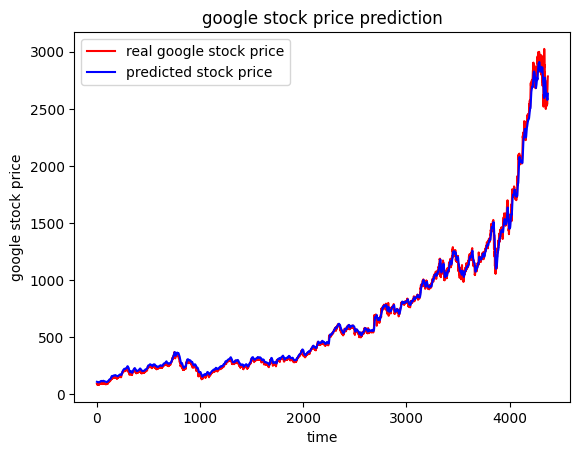

In [39]:
plt.plot(
    scaler.inverse_transform(y_train.reshape(-1,1)),
    color='red',
    label='real google stock price'
)

plt.plot(
    predicted_stock_price,
    color='blue',
    label='predicted stock price'
)

plt.title('google stock price prediction')

plt.xlabel('time')

plt.ylabel('google stock price')

plt.legend()

plt.show()